Name: Ritesh Chaudhary
Id:2438464

**Step 0 — Imports & Setup**

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import matplotlib.pyplot as plt
from PIL import Image

print(f"TensorFlow: {tf.__version__}")
print(f"Keras: {keras.__version__}")

TensorFlow: 2.19.0
Keras: 3.13.2


**Task 1 — Load & Preprocess the Data**

In [ ]:
import zipfile
from tqdm import tqdm

zip_path   = "/content/drive/MyDrive/AI ko ho/Week-4/Copy of devnagari digit.zip"
extract_to = "/content/devnagari/"

os.makedirs(extract_to, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    members = zip_ref.infolist()
    for member in tqdm(members, desc="Extracting"):
        zip_ref.extract(member, extract_to)

print("✅ Extraction complete!")

Extracting: 100%|██████████| 20000/20000 [00:04<00:00, 4840.65it/s]

✅ Extraction complete!


**Check Folder Structure**

In [ ]:
# Run this to see what got extracted, then set paths below
for root, dirs, files in os.walk(extract_to):
    level = root.replace(extract_to, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    if level >= 2:
        break

/
DevanagariHandwrittenDigitDataset/
  Test/
    digit_6/


** Load Images Using PIL**

In [ ]:
# Update these if the printed structure above shows different folder names
TRAIN_DIR   = "/content/devnagari/DevanagariHandwrittenDigitDataset/Train/"
TEST_DIR    = "/content/devnagari/DevanagariHandwrittenDigitDataset/Test/"
IMG_HEIGHT  = 28
IMG_WIDTH   = 28
NUM_CLASSES = 10

def load_images_from_folder(folder):
    images, labels = [], []
    class_names = sorted(os.listdir(folder))           # digit_0, digit_1 ...
    class_map   = {name: i for i, name in enumerate(class_names)}
    print(f"  Classes found: {class_map}")

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        if not os.path.isdir(class_path):
            continue
        label = class_map[class_name]
        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            try:
                img = Image.open(img_path).convert("L")               # grayscale
                img = img.resize((IMG_WIDTH, IMG_HEIGHT))              # resize 28x28
                img = np.array(img, dtype=np.float32) / 255.0         # normalize [0,1]
                images.append(img)
                labels.append(label)
            except Exception as e:
                print(f"  Skipping {img_path}: {e}")

    return np.array(images), np.array(labels)

print("Loading training data...")
x_train_raw, y_train_raw = load_images_from_folder(TRAIN_DIR)

print("\nLoading test data...")
x_test_raw, y_test_raw = load_images_from_folder(TEST_DIR)

Loading training data...
  Classes found: {'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}

Loading test data...
  Classes found: {'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}


**Flatten & One-Hot Encode**

In [ ]:
# Flatten 28x28 images → 784 vector (needed for Dense layers)
x_train = x_train_raw.reshape(-1, IMG_HEIGHT * IMG_WIDTH)
x_test  = x_test_raw.reshape(-1, IMG_HEIGHT * IMG_WIDTH)

# One-hot encode: e.g. label 3 → [0,0,0,1,0,0,0,0,0,0]
y_train = to_categorical(y_train_raw, num_classes=NUM_CLASSES)
y_test  = to_categorical(y_test_raw,  num_classes=NUM_CLASSES)

print(f"x_train shape : {x_train.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"x_test  shape : {x_test.shape}")
print(f"y_test  shape : {y_test.shape}")

x_train shape : (17000, 784)
y_train shape : (17000, 10)
x_test  shape : (3000, 784)
y_test  shape : (3000, 10)


Visualise Sample Images

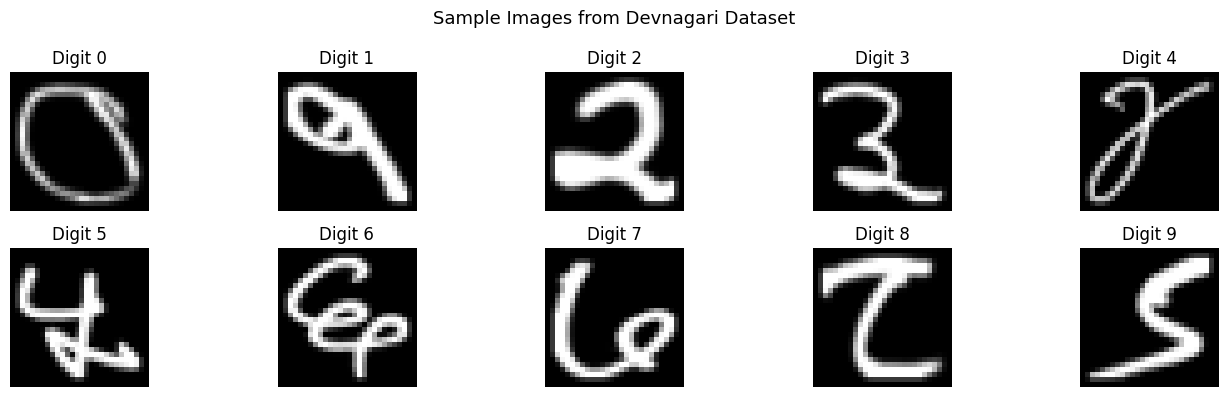

In [ ]:
plt.figure(figsize=(14, 4))
for i in range(NUM_CLASSES):
    idx = np.where(y_train_raw == i)[0][0]
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_raw[idx], cmap='gray')
    plt.title(f"Digit {i}")
    plt.axis('off')
plt.suptitle("Sample Images from Devnagari Dataset", fontsize=13)
plt.tight_layout()
plt.show()

**Task 2 — Build the FCN Model**

In [ ]:
model = Sequential([
    Input(shape=(IMG_HEIGHT * IMG_WIDTH,)),
    Dense(64,  activation='relu', name='hidden_1'),   # changed sigmoid → relu
    Dense(128, activation='relu', name='hidden_2'),   # changed sigmoid → relu
    Dense(256, activation='relu', name='hidden_3'),   # changed sigmoid → relu
    Dense(NUM_CLASSES, activation='softmax', name='output_layer'),
], name='devnagari_fcn')

model.summary()

Model: "devnagari_fcn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

**Task 3 — Compile the Model**

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model compiled successfully.")

✅ Model compiled successfully.


**Task 4 — Train the Model**

**Set Up Callbacks**

In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath='best_devnagari_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
]

Run Training

In [ ]:
history = model.fit(
    x_train, y_train,
    batch_size=128,
    epochs=50,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
100/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6841 - loss: 0.9989
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_devnagari_model.keras

Epoch 1: finished saving model to best_devnagari_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8425 - loss: 0.5037 - val_accuracy: 0.0000e+00 - val_loss: 15.5252
Epoch 2/50
105/107 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9461 - loss: 0.1629
Epoch 2: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9522 - loss: 0.1469 - val_accuracy: 0.0000e+00 - val_loss: 15.8082
Epoch 3/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9697 - loss: 0.1031
Epoch 3: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9725 - loss: 0.0926 - val_accuracy: 0.0000e+00 - val_loss: 16.6650
Epoch 4/50
105/107 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9782 - loss: 0.0725
Epoch 4: val_accuracy did not

Plot Training Curves

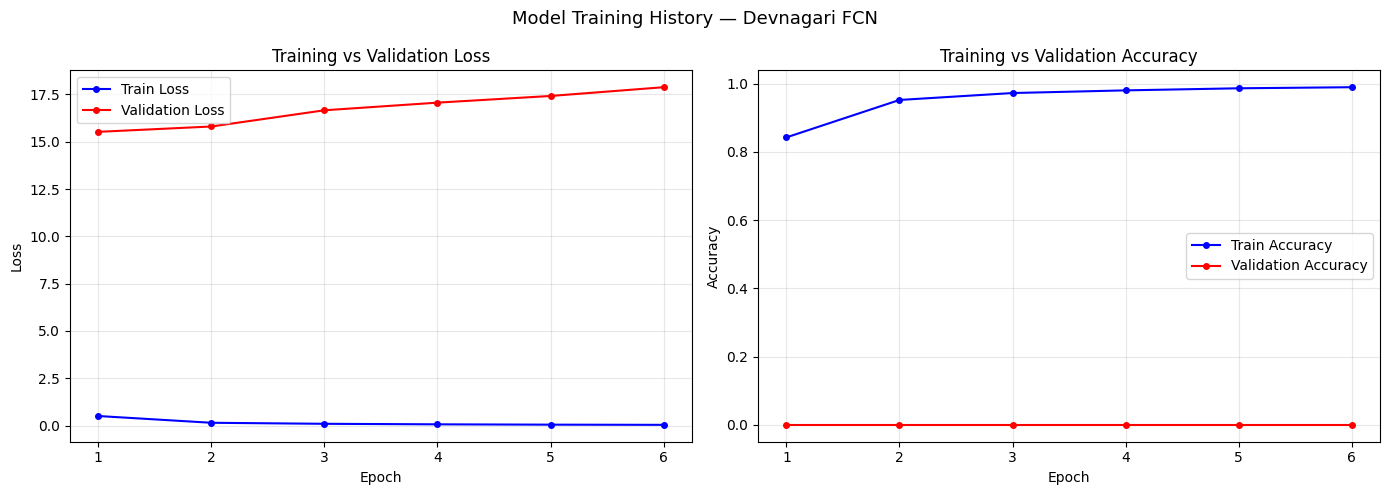

In [ ]:
train_loss = history.history['loss']
val_loss   = history.history['val_loss']
train_acc  = history.history['accuracy']
val_acc    = history.history['val_accuracy']
epochs_ran = range(1, len(train_loss) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
ax1.plot(epochs_ran, train_loss, 'b-o', label='Train Loss',      markersize=4)
ax1.plot(epochs_ran, val_loss,   'r-o', label='Validation Loss', markersize=4)
ax1.set_title('Training vs Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Accuracy plot
ax2.plot(epochs_ran, train_acc, 'b-o', label='Train Accuracy',      markersize=4)
ax2.plot(epochs_ran, val_acc,   'r-o', label='Validation Accuracy', markersize=4)
ax2.set_title('Training vs Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Model Training History — Devnagari FCN', fontsize=13)
plt.tight_layout()
plt.show()

**Task 5 — Evaluate the Model**

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)

print(f"\n✅ Test Loss     : {test_loss:.4f}")
print(f"✅ Test Accuracy : {test_acc*100:.2f}%")

94/94 - 0s - 2ms/step - accuracy: 0.7503 - loss: 3.2263

✅ Test Loss     : 3.2263
✅ Test Accuracy : 75.03%


**Task 6 — Save & Load the Model**

Save the Model

In [ ]:
model.save('devnagari_fcn_model.h5')
print("✅ Model saved as devnagari_fcn_model.h5")

✅ Model saved as devnagari_fcn_model.h5


Load the Model & Re-Evaluate

In [ ]:
loaded_model = tf.keras.models.load_model('devnagari_fcn_model.h5')
print("✅ Model loaded successfully.")

loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test, verbose=2)
print(f"\nLoaded Model — Test Loss     : {loaded_loss:.4f}")
print(f"Loaded Model — Test Accuracy : {loaded_acc*100:.2f}%")

✅ Model loaded successfully.
94/94 - 1s - 6ms/step - accuracy: 0.7503 - loss: 3.2263

Loaded Model — Test Loss     : 3.2263
Loaded Model — Test Accuracy : 75.03%


**Task 7 — Make Predictions**


Run Predictions

In [ ]:
predictions      = loaded_model.predict(x_test, verbose=0)
predicted_labels = np.argmax(predictions, axis=1)   # highest prob → class label
true_labels      = np.argmax(y_test, axis=1)

print(f"First image → Predicted: {predicted_labels[0]},  True: {true_labels[0]}")

First image → Predicted: 0,  True: 0


Visualise Predictions

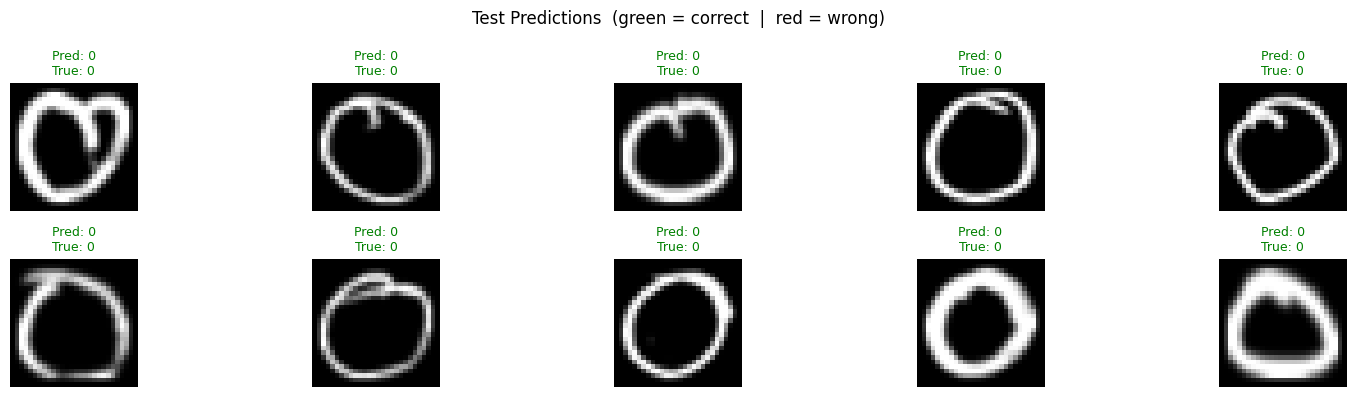

In [ ]:
plt.figure(figsize=(16, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test_raw[i], cmap='gray')
    color = 'green' if predicted_labels[i] == true_labels[i] else 'red'
    plt.title(f"Pred: {predicted_labels[i]}\nTrue: {true_labels[i]}",
              color=color, fontsize=9)
    plt.axis('off')
plt.suptitle("Test Predictions  (green = correct  |  red = wrong)", fontsize=12)
plt.tight_layout()
plt.show()

Final Accuracy Check

In [ ]:
correct = np.sum(predicted_labels == true_labels)
total   = len(true_labels)
print(f"✅ Correct predictions : {correct} / {total}")
print(f"✅ Final Accuracy      : {correct / total * 100:.2f}%")

✅ Correct predictions : 2251 / 3000
✅ Final Accuracy      : 75.03%
